# V2 Projection

This notebook reads `tmp/v2/new_thermal_bbox.csv`, validates the existing CSV timestamp, standardizes bbox columns, projects bbox coordinates to the 2D room map, applies layout constraints to Machine and Screen, and plots projected positions by label.

All v2 outputs are written under `tmp/v2/` and separated by processing stage.

In [1]:
# load project paths and local modules.
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import v2_config
from v2_01_projection import run_projection


In [2]:
# define v2 input and output files.
INPUT_CSV = v2_config.V2_RAW_BBOX_CSV
STANDARDIZED_CSV = v2_config.V2_STANDARDIZED_BBOX_CSV
PROJECTED_CSV = v2_config.V2_PROJECTED_DETECTIONS_CSV
PROJECTION_PREVIEW_PNG = v2_config.V2_PROJECTION_PREVIEW_PNG
LAYOUT_IMAGE = v2_config.LAYOUT_IMAGE
# offset from the previous process (crop the scale bar)
RAW_BBOX_X_OFFSET = 70

v2_config.ensure_v2_output_dirs()

{
    'input_csv': INPUT_CSV,
    'standardized_csv': STANDARDIZED_CSV,
    'projected_csv': PROJECTED_CSV,
    'projection_preview_png': PROJECTION_PREVIEW_PNG,
    'layout_image': LAYOUT_IMAGE,
    'raw_bbox_x_offset_px': RAW_BBOX_X_OFFSET,
}


{'input_csv': PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/new_thermal_bbox.csv'),
 'standardized_csv': PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/input/v2_thermal_bbox_standardized.csv'),
 'projected_csv': PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/projection/v2_projected_detections.csv'),
 'projection_preview_png': PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/projection/v2_projected_points_by_label.png'),
 'layout_image': PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/feynman_room_layout_without_axis.png'),
 'raw_bbox_x_offset_px': 70}

In [3]:
# read the new bbox and temperature CSV.
raw_df = pd.read_csv(INPUT_CSV)
print(f'rows: {len(raw_df):,}')
print(f'columns: {list(raw_df.columns)}')
display(raw_df.head())


rows: 237,515
columns: ['filename', 'timestamp', 'class_name', 'box_x0', 'bbox_y0', 'bbox_x1', 'bbox_y1', 'temp_mean_c', 'temp_max_c', 'pixels', 'confidence']


,filename,timestamp,class_name,box_x0,bbox_y0,bbox_x1,bbox_y1,temp_mean_c,temp_max_c,pixels,confidence
0,IR_63142.jpg,2025/5/1 15:19,Machine,461,298,483,318,21.886789,25.424925,106,0.822366
1,IR_63142.jpg,2025/5/1 15:19,Machine,467,256,491,280,22.069757,25.502478,174,0.854753
2,IR_63142.jpg,2025/5/1 15:19,Machine,404,248,438,271,21.645502,23.766699,194,0.834977
3,IR_63142.jpg,2025/5/1 15:19,Machine,416,212,435,230,22.321835,25.575266,72,0.773920
4,IR_63142.jpg,2025/5/1 15:19,Machine,452,207,507,248,23.885866,25.676907,925,0.903655


## Timestamp Validation

Rows with a complete timestamp are marked `timestamp_valid = Y` and kept. Rows with incomplete or invalid timestamp strings are marked `N` and removed before projection.

In [4]:
# validate timestamp strings and standardize them to yyyy-mm-dd hh:mm:ss.
TIMESTAMP_FORMATS = [
    '%Y/%m/%d %H:%M:%S',
    '%Y/%m/%d %H:%M',
    '%Y-%m-%d %H:%M:%S',
    '%Y-%m-%d %H:%M',
]


def parse_complete_timestamp(value):
    value = str(value).strip()
    for fmt in TIMESTAMP_FORMATS:
        parsed = pd.to_datetime(value, format=fmt, errors='coerce')
        if pd.notna(parsed):
            return parsed
    return pd.NaT


timestamp_parsed = raw_df['timestamp'].apply(parse_complete_timestamp)
timestamp_valid = timestamp_parsed.notna()

timestamp_summary = {
    'input_rows': len(raw_df),
    'valid_timestamp_rows': int(timestamp_valid.sum()),
    'removed_invalid_timestamp_rows': int((~timestamp_valid).sum()),
    'removed_share_percent': round((~timestamp_valid).mean() * 100, 2),
}

display(timestamp_summary)
display(raw_df.loc[~timestamp_valid, ['filename', 'timestamp', 'class_name']].head(20))


{'input_rows': 237515,
 'valid_timestamp_rows': 219335,
 'removed_invalid_timestamp_rows': 18180,
 'removed_share_percent': 7.65}

,filename,timestamp,class_name
109080,IR_58299.jpg,34:34.0,Light
109081,IR_58299.jpg,34:34.0,Light
109082,IR_58299.jpg,34:34.0,Light
109083,IR_58299.jpg,34:34.0,Light
109084,IR_58299.jpg,34:34.0,Screen
109085,IR_59187.jpg,56:20.0,Machine
109086,IR_59187.jpg,56:20.0,Machine
109087,IR_59187.jpg,56:20.0,Machine
109088,IR_59187.jpg,56:20.0,Machine
109089,IR_59187.jpg,56:20.0,Machine


In [5]:
# standardize column names and keep only timestamp-valid rows.
standard_df = raw_df.rename(
    columns={
        'filename': 'image_name',
        'class_name': 'label',
        'box_x0': 'bbox_x0',
    }
).copy()

standard_df['timestamp'] = timestamp_parsed.dt.strftime('%Y-%m-%d %H:%M:%S')
standard_df['timestamp_valid'] = timestamp_valid.map({True: 'Y', False: 'N'})
standard_df['detection_index'] = standard_df.groupby('image_name').cumcount() + 1

ordered_columns = [
    'image_name',
    'timestamp',
    'timestamp_valid',
    'detection_index',
    'label',
    'bbox_x0',
    'bbox_y0',
    'bbox_x1',
    'bbox_y1',
    'temp_mean_c',
    'temp_max_c',
    'pixels',
    'confidence',
]
standard_df = standard_df[ordered_columns]

# raw bbox source was cropped by 70 px on the x axis; add it back before projection.
for column in ['bbox_x0', 'bbox_x1']:
    standard_df[column] = pd.to_numeric(standard_df[column], errors='coerce') + RAW_BBOX_X_OFFSET

valid_df = standard_df[standard_df['timestamp_valid'] == 'Y'].copy()
valid_df.to_csv(STANDARDIZED_CSV, index=False)

print(f'wrote: {STANDARDIZED_CSV}')
print(f'kept rows: {len(valid_df):,}')
print(f'removed rows: {len(standard_df) - len(valid_df):,}')
print(f'raw bbox x offset applied: {RAW_BBOX_X_OFFSET}px')
display(valid_df.head())


wrote: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/input/v2_thermal_bbox_standardized.csv
kept rows: 219,335
removed rows: 18,180
raw bbox x offset applied: 70px


,image_name,timestamp,timestamp_valid,detection_index,label,bbox_x0,bbox_y0,bbox_x1,bbox_y1,temp_mean_c,temp_max_c,pixels,confidence
0,IR_63142.jpg,2025-05-01 15:19:00,Y,1,Machine,531,298,553,318,21.886789,25.424925,106,0.822366
1,IR_63142.jpg,2025-05-01 15:19:00,Y,2,Machine,537,256,561,280,22.069757,25.502478,174,0.854753
2,IR_63142.jpg,2025-05-01 15:19:00,Y,3,Machine,474,248,508,271,21.645502,23.766699,194,0.834977
3,IR_63142.jpg,2025-05-01 15:19:00,Y,4,Machine,486,212,505,230,22.321835,25.575266,72,0.773920
4,IR_63142.jpg,2025-05-01 15:19:00,Y,5,Machine,522,207,577,248,23.885866,25.676907,925,0.903655


In [6]:
# run projection on the standardized bbox rows.
projection_args = SimpleNamespace(
    input_csv=STANDARDIZED_CSV,
    output_csv=PROJECTED_CSV,
    human_model_path=v2_config.HUMAN_PROJECTION_MODEL_PATH,
    machine_model_path=v2_config.MACHINE_PROJECTION_MODEL_PATH,
    normalized_factor=v2_config.NORMALIZED_FACTOR,
)

projected_rows = run_projection(projection_args)
len(projected_rows), projected_rows[:2]


V2 projection: 100%|██████████| 219335/219335 [00:13<00:00, 16234.35object/s]


(219335,
 [{'image_name': 'IR_63142.jpg',
   'timestamp': '2025-05-01 15:19:00',
   'timestamp_valid': 'Y',
   'detection_index': '1',
   'label': 'Machine',
   'bbox_x0': '531',
   'bbox_y0': '298',
   'bbox_x1': '553',
   'bbox_y1': '318',
   'temp_mean_c': '21.886789321899418',
   'temp_max_c': '25.424924850463867',
   'pixels': '106',
   'confidence': '0.8223658867602078',
   'projected_x': '8.726787',
   'projected_y': '3.638916'},
  {'image_name': 'IR_63142.jpg',
   'timestamp': '2025-05-01 15:19:00',
   'timestamp_valid': 'Y',
   'detection_index': '2',
   'label': 'Machine',
   'bbox_x0': '537',
   'bbox_y0': '256',
   'bbox_x1': '561',
   'bbox_y1': '280',
   'temp_mean_c': '22.06975746154785',
   'temp_max_c': '25.502477645874023',
   'pixels': '174',
   'confidence': '0.8547529023269127',
   'projected_x': '8.075858',
   'projected_y': '3.783144'}])

In [7]:
# preview the projected output and class distribution.
projected_df = pd.read_csv(PROJECTED_CSV)
print(f'wrote: {PROJECTED_CSV}')
display(projected_df.head())
display(projected_df['label'].value_counts(dropna=False))


wrote: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/projection/v2_projected_detections.csv


,image_name,timestamp,timestamp_valid,detection_index,label,bbox_x0,bbox_y0,bbox_x1,bbox_y1,temp_mean_c,temp_max_c,pixels,confidence,projected_x,projected_y
0,IR_63142.jpg,2025-05-01 15:19:00,Y,1,Machine,531,298,553,318,21.886789,25.424925,106,0.822366,8.726787,3.638916
1,IR_63142.jpg,2025-05-01 15:19:00,Y,2,Machine,537,256,561,280,22.069757,25.502478,174,0.854753,8.075858,3.783144
2,IR_63142.jpg,2025-05-01 15:19:00,Y,3,Machine,474,248,508,271,21.645502,23.766699,194,0.834977,7.393746,3.656946
3,IR_63142.jpg,2025-05-01 15:19:00,Y,4,Machine,486,212,505,230,22.321835,25.575266,72,0.773920,6.418335,3.631017
4,IR_63142.jpg,2025-05-01 15:19:00,Y,5,Machine,522,207,577,248,23.885866,25.676907,925,0.903655,6.499782,3.895448


label
Machine    126359
Light       57408
Screen      14852
Window      11995
Person       8721
Name: count, dtype: int64

In [8]:
# inspect projected output columns.
projected_df = pd.read_csv(PROJECTED_CSV)
print(f'wrote: {PROJECTED_CSV}')
print(f'rows: {len(projected_df):,}')
print(f'columns: {list(projected_df.columns)}')
display(projected_df.head())
display(projected_df['label'].value_counts(dropna=False))


wrote: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/projection/v2_projected_detections.csv
rows: 219,335
columns: ['image_name', 'timestamp', 'timestamp_valid', 'detection_index', 'label', 'bbox_x0', 'bbox_y0', 'bbox_x1', 'bbox_y1', 'temp_mean_c', 'temp_max_c', 'pixels', 'confidence', 'projected_x', 'projected_y']


,image_name,timestamp,timestamp_valid,detection_index,label,bbox_x0,bbox_y0,bbox_x1,bbox_y1,temp_mean_c,temp_max_c,pixels,confidence,projected_x,projected_y
0,IR_63142.jpg,2025-05-01 15:19:00,Y,1,Machine,531,298,553,318,21.886789,25.424925,106,0.822366,8.726787,3.638916
1,IR_63142.jpg,2025-05-01 15:19:00,Y,2,Machine,537,256,561,280,22.069757,25.502478,174,0.854753,8.075858,3.783144
2,IR_63142.jpg,2025-05-01 15:19:00,Y,3,Machine,474,248,508,271,21.645502,23.766699,194,0.834977,7.393746,3.656946
3,IR_63142.jpg,2025-05-01 15:19:00,Y,4,Machine,486,212,505,230,22.321835,25.575266,72,0.773920,6.418335,3.631017
4,IR_63142.jpg,2025-05-01 15:19:00,Y,5,Machine,522,207,577,248,23.885866,25.676907,925,0.903655,6.499782,3.895448


label
Machine    126359
Light       57408
Screen      14852
Window      11995
Person       8721
Name: count, dtype: int64

wrote: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/projection/v2_projected_points_by_label.png


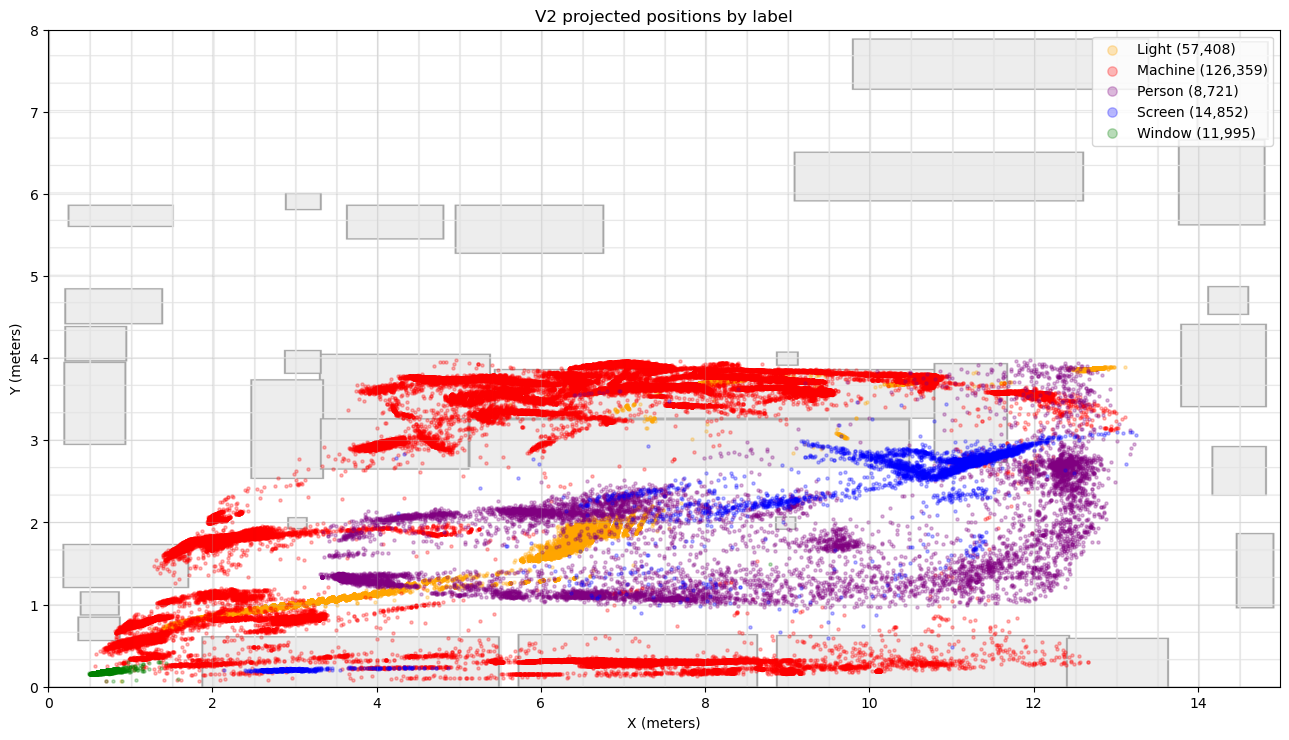

In [9]:
# plot projected 2D positions by label on the cleanroom map.
plot_df = projected_df.copy()
plot_df['projected_x'] = pd.to_numeric(plot_df['projected_x'], errors='coerce')
plot_df['projected_y'] = pd.to_numeric(plot_df['projected_y'], errors='coerce')
plot_df = plot_df.dropna(subset=['projected_x', 'projected_y', 'label'])

label_colors = {
    'Machine': 'red',
    'Light': 'orange',
    'Screen': 'blue',
    'Window': 'green',
    'Person': 'purple',
}

fig, ax = plt.subplots(figsize=(13, 8))
if LAYOUT_IMAGE.exists():
    layout = mpimg.imread(LAYOUT_IMAGE)
    ax.imshow(layout, extent=[0, 15, 0, 8], origin='upper', alpha=0.35)

for label, group in plot_df.groupby('label'):
    ax.scatter(
        group['projected_x'],
        group['projected_y'],
        s=5,
        alpha=0.28,
        color=label_colors.get(label, 'gray'),
        label=f'{label} ({len(group):,})',
    )

ax.set_title('V2 projected positions by label')
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_xlim(0, 15)
ax.set_ylim(0, 8)
ax.grid(alpha=0.25)
ax.legend(loc='best', markerscale=3)
fig.tight_layout()
fig.savefig(PROJECTION_PREVIEW_PNG, dpi=140, bbox_inches='tight')
print(f'wrote: {PROJECTION_PREVIEW_PNG}')


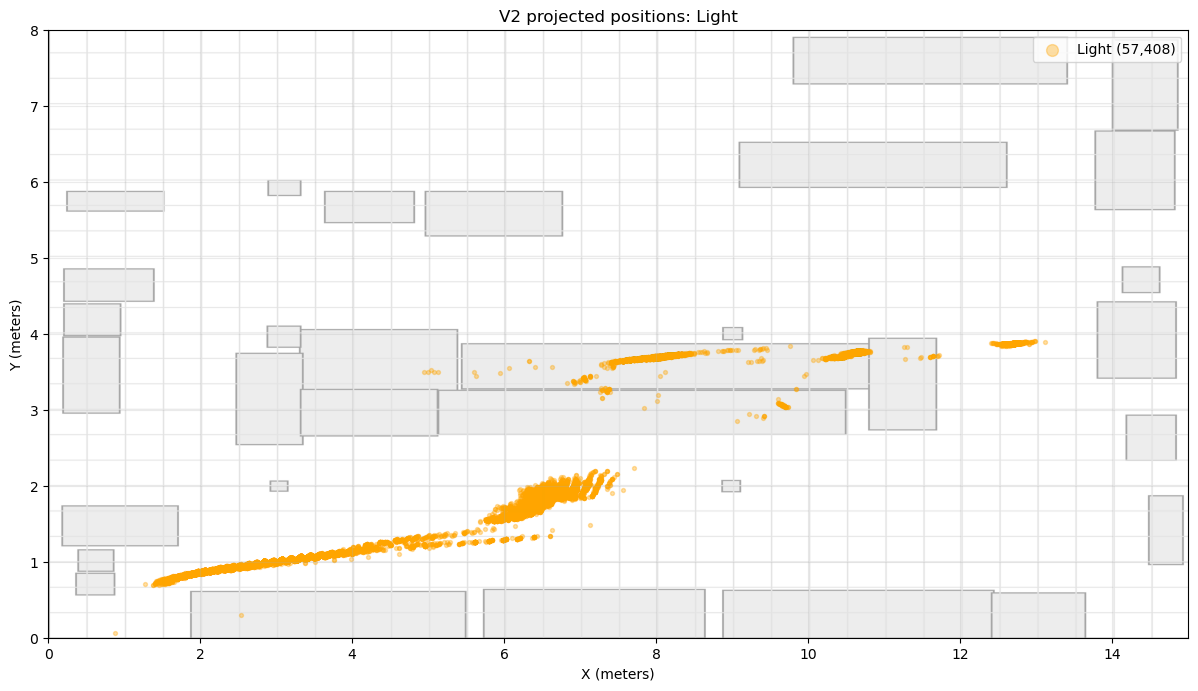

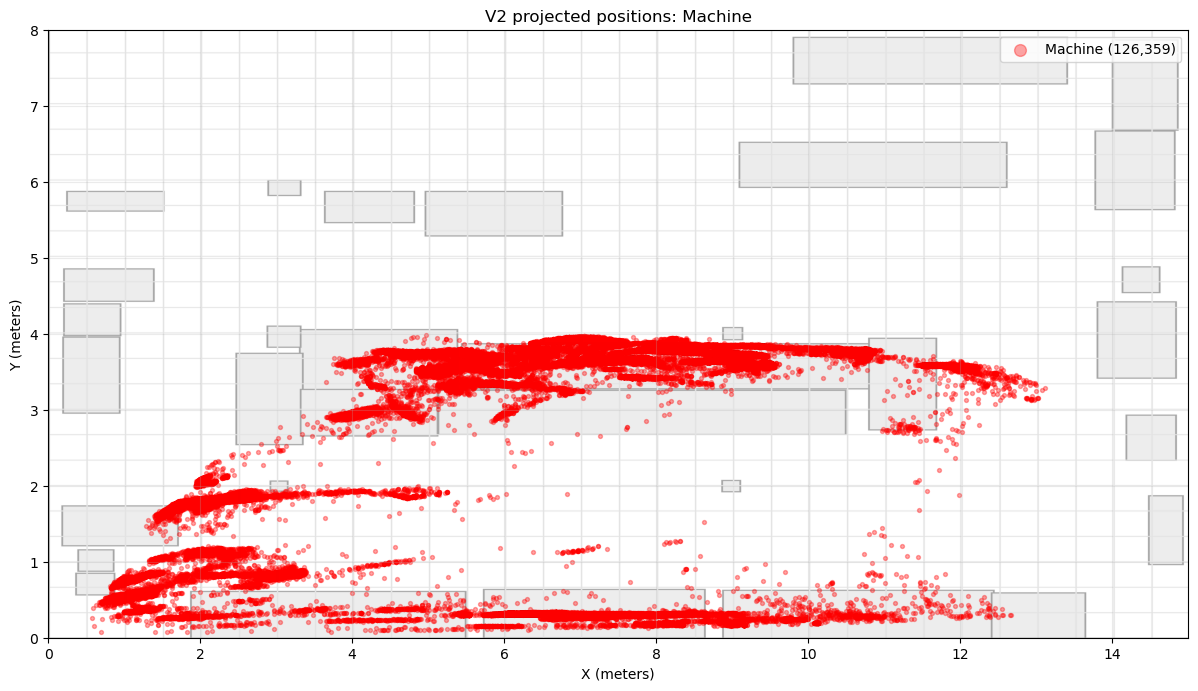

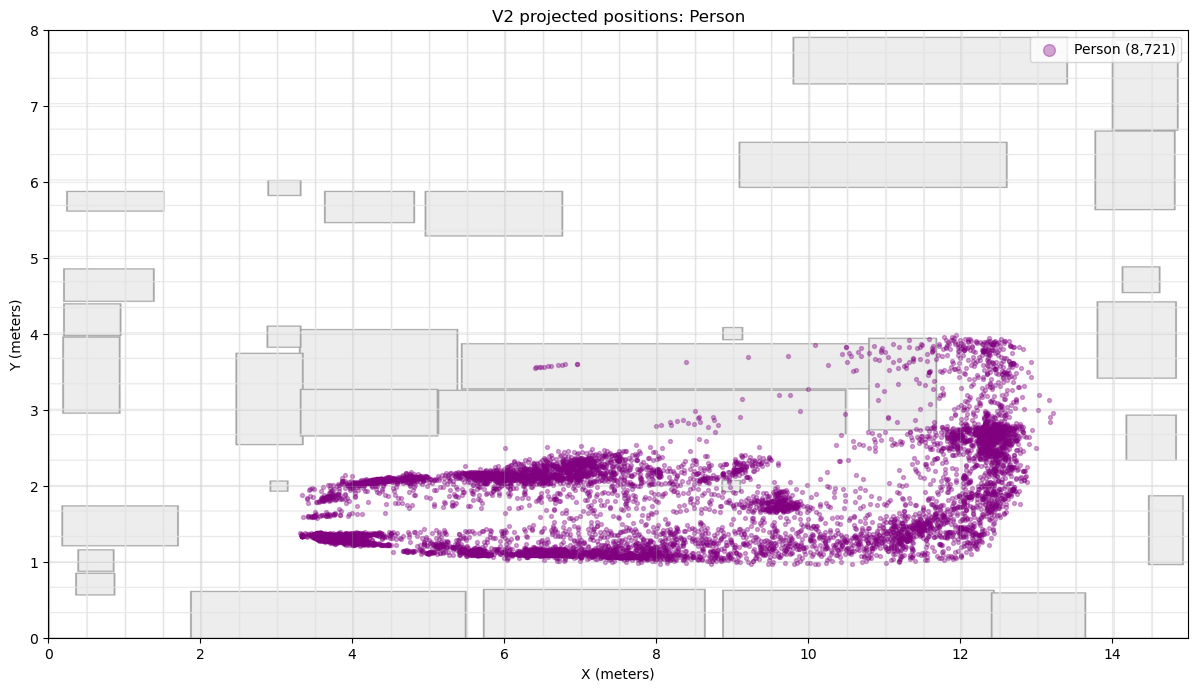

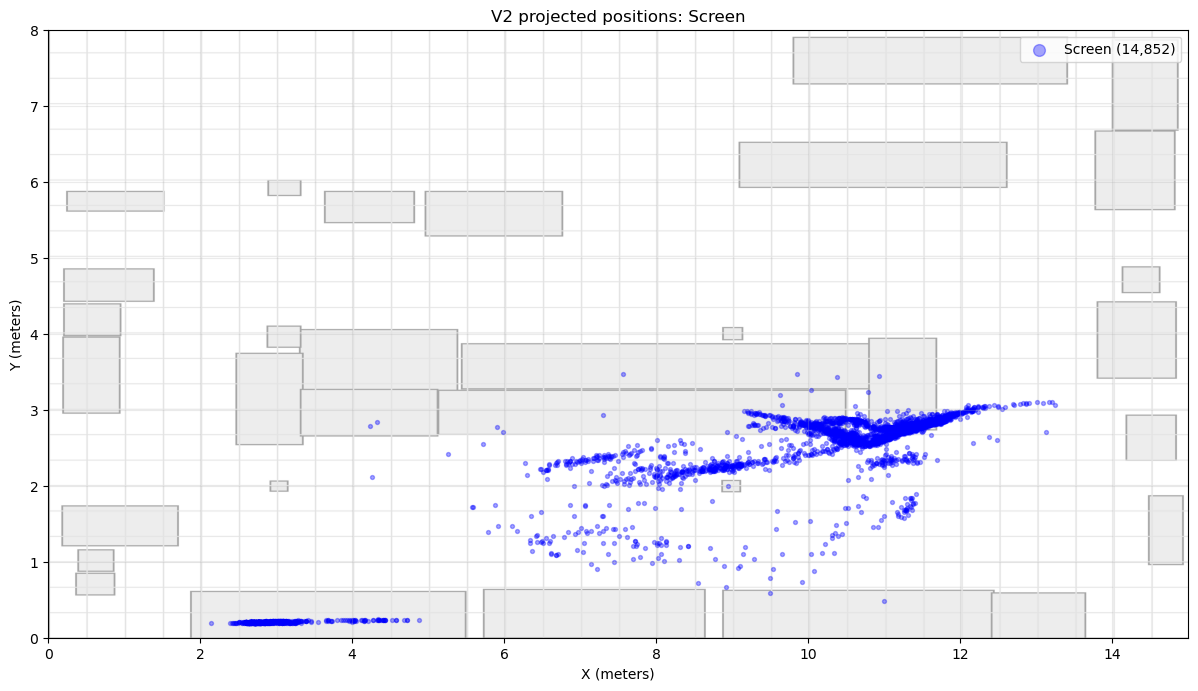

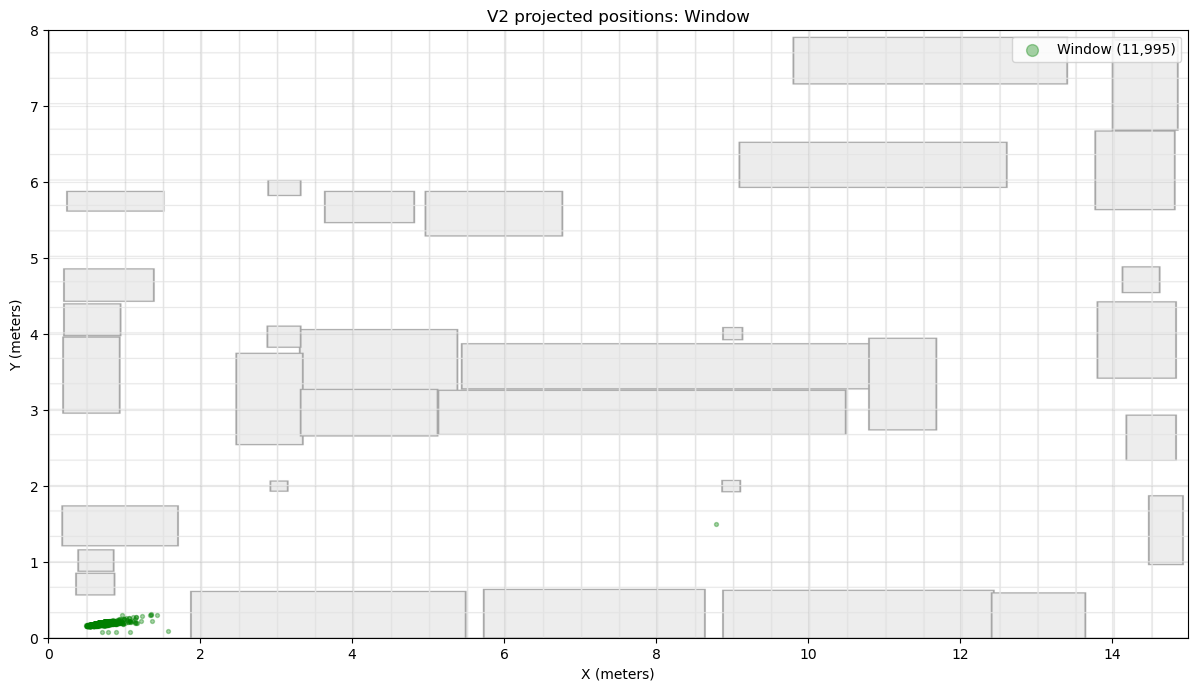

In [10]:
# plot one layout figure per label using the prepared plot_df.
for label in sorted(plot_df['label'].unique()):
    label_df = plot_df[plot_df['label'] == label]

    fig, ax = plt.subplots(figsize=(13, 7))

    ax.imshow(
        layout,
        extent=[0, v2_config.MAP_WIDTH, 0, v2_config.MAP_HEIGHT],
        origin='upper',
        alpha=0.35,
    )

    ax.scatter(
        label_df['projected_x'],
        label_df['projected_y'],
        s=8,
        alpha=0.35,
        color=label_colors.get(label, 'gray'),
        label=f'{label} ({len(label_df):,})',
    )

    ax.set_xlim(0, v2_config.MAP_WIDTH)
    ax.set_ylim(0, v2_config.MAP_HEIGHT)
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_title(f'V2 projected positions: {label}')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', markerscale=3)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


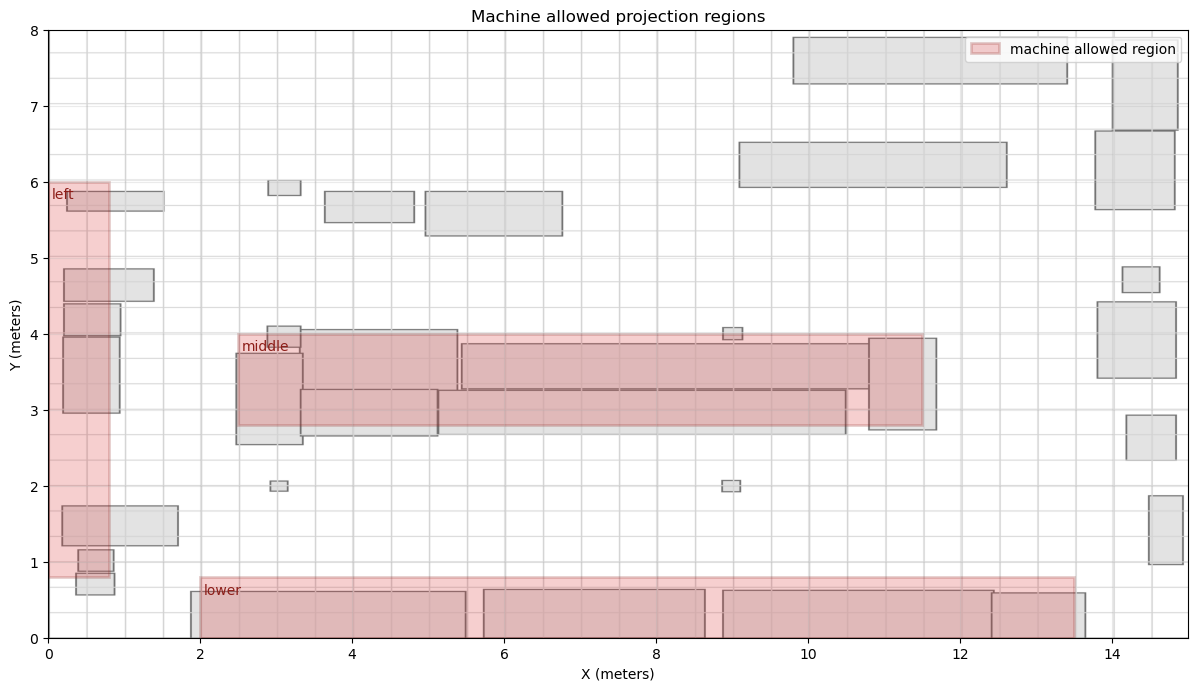

In [11]:
# plot allowed projection regions for machine points.
machine_regions = [
    ("left", 0.0, 0.8, 0.8, 6.0),
    ("middle", 2.5, 2.8, 11.5, 4.0),
    ("lower", 2.0, 0.0, 13.5, 0.8),
]

layout_img = plt.imread(v2_config.LAYOUT_IMAGE)

fig, ax = plt.subplots(figsize=(13, 7))
ax.imshow(
    layout_img,
    extent=[0, v2_config.MAP_WIDTH, 0, v2_config.MAP_HEIGHT],
    origin='upper',
    alpha=0.55,
)

for region_name, x1, y1, x2, y2 in machine_regions:
    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        facecolor='#d62728',
        edgecolor='#8c1d18',
        linewidth=2.0,
        alpha=0.22,
        label='machine allowed region' if region_name == machine_regions[0][0] else None,
    )
    ax.add_patch(rect)
    ax.text(
        x1 + 0.05,
        y2 - 0.08,
        region_name,
        color='#8c1d18',
        fontsize=10,
        va='top',
        ha='left',
    )

ax.set_xlim(0, v2_config.MAP_WIDTH)
ax.set_ylim(0, v2_config.MAP_HEIGHT)
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_title('Machine allowed projection regions')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
